# Data Handling & Visualization 5 — Charts, graphs, and trend analysis

**Digital Foundation for Chemical Engineers**  \n
Duration: 60 minutes

## Today’s goal
Choose an appropriate chart, construct readable industrial plots, and describe a trend without claiming more than the data show.

## 1. Match the chart to the question (10 min)

- **Line chart:** how a value changes over ordered time.
- **Scatter plot:** whether two numerical variables appear related.
- **Bar chart:** compare categories or summary values.

Every engineering chart needs a descriptive title, labelled axes with units, and a readable scale. Avoid 3D charts and unexplained decorative elements.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

hourly = pd.read_csv('data/industrial_process_100.csv').head(24).copy()
hourly['timestamp'] = pd.to_datetime(hourly['timestamp'])
hourly

,timestamp,batch_id,reactor,temperature_c,pressure_bar,flow_m3_h,conversion_percent,ph,operator,sample_status
0,2026-01-05 08:00:00,B1001,R1,73.0,4.65,11.70,87.5,6.70,Asha,OK
1,2026-01-05 09:00:00,B1001,R2,73.6,4.71,11.81,88.0,6.79,Bimal,OK
2,2026-01-05 10:00:00,B1001,R3,74.2,4.76,11.92,88.5,6.88,Chen,OK
3,2026-01-05 11:00:00,B1001,R1,74.9,4.82,12.03,89.1,6.97,Deepa,OK
4,2026-01-05 12:00:00,B1001,R2,75.5,4.87,12.14,89.6,7.06,Asha,OK
5,2026-01-05 13:00:00,B1001,R3,76.1,4.93,12.25,90.1,7.15,Bimal,OK
6,2026-01-05 14:00:00,B1001,R1,76.7,4.98,12.36,90.6,7.24,Chen,OK
7,2026-01-05 15:00:00,B1001,R2,77.3,5.04,12.47,91.1,6.70,Deepa,OK
8,2026-01-05 16:00:00,B1001,R3,78.0,5.09,12.58,91.7,6.79,Asha,OK
9,2026-01-05 17:00:00,B1001,R1,78.6,5.15,11.70,92.2,6.88,Bimal,OK


## 2. Line chart: process trend (15 min)

A line chart makes sense when the x-axis has a natural order, especially time. Markers make individual readings visible; `grid()` helps interpretation without overwhelming the data.

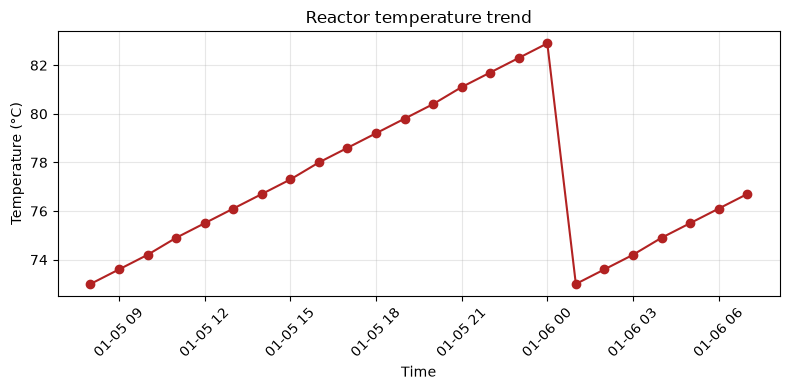

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(hourly['timestamp'], hourly['temperature_c'], marker='o', color='firebrick')
plt.title('Reactor temperature trend')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Try it (4 min):** Plot flow rate against time. Give it a proper title and axes labels.

**Challenge:** Add a horizontal target line at 80 °C with `plt.axhline(80, ...)` and a legend.

## 3. Scatter plot: possible relationship (12 min)

A scatter plot can suggest a relationship, but it cannot by itself establish causation. Check whether the process conditions, sampling, and engineering mechanism support the idea.

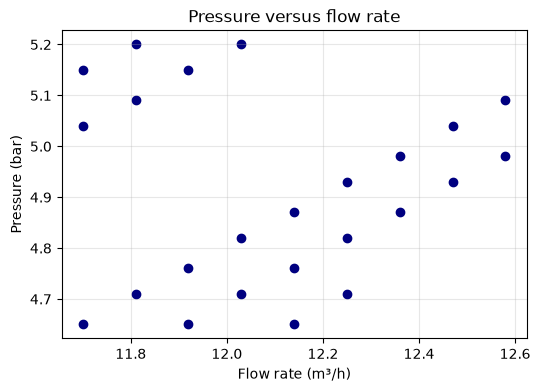

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(hourly['flow_m3_h'], hourly['pressure_bar'], color='navy')
plt.title('Pressure versus flow rate')
plt.xlabel('Flow rate (m³/h)')
plt.ylabel('Pressure (bar)')
plt.grid(True, alpha=0.3)
plt.show()

**Discuss (3 min):** Does this plot appear to show a positive, negative, or no clear association? What other variables could influence pressure?

**Challenge:** Calculate `hourly[['flow_m3_h', 'pressure_bar']].corr()` and explain why correlation is not proof of cause.

## 4. Bar chart: compare categories (10 min)

Bar charts work well for a small number of categories. Use a zero baseline unless there is a clearly communicated reason not to; otherwise visual differences can be misleading.

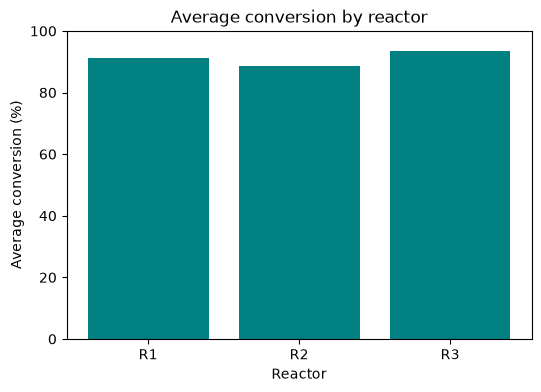

In [5]:
conversion_by_reactor = pd.Series({'R1': 91.2, 'R2': 88.7, 'R3': 93.5})
plt.figure(figsize=(6, 4))
plt.bar(conversion_by_reactor.index, conversion_by_reactor.values, color='teal')
plt.title('Average conversion by reactor')
plt.xlabel('Reactor')
plt.ylabel('Average conversion (%)')
plt.ylim(0, 100)
plt.show()

## Pair task: visual conclusion (10 min)

Create one chart from `hourly` that answers a useful operating question. Beneath it, write two sentences: one observation supported by the chart and one limitation.

**Challenge:** Use `plt.subplots(1, 2, figsize=(12, 4))` to create a compact two-chart reporting view.

In [ ]:
# Your chart and written conclusion




## Exit check

You can select line, scatter, or bar charts appropriately; label plots clearly; and distinguish an observed trend from a causal claim. Next: dashboards and concise reporting.